102.26666666666667
50.63333333333333
[  13.1162826    20.57017643   35.8963894    87.51489821   91.41358254
  122.75524635  143.03446347  194.40391637  717.42020484  776.52237378
  786.03741783  847.92548727  869.29064446 1069.42640057 1943.39888817
 2308.14618236 2684.6193277  2685.78069036]


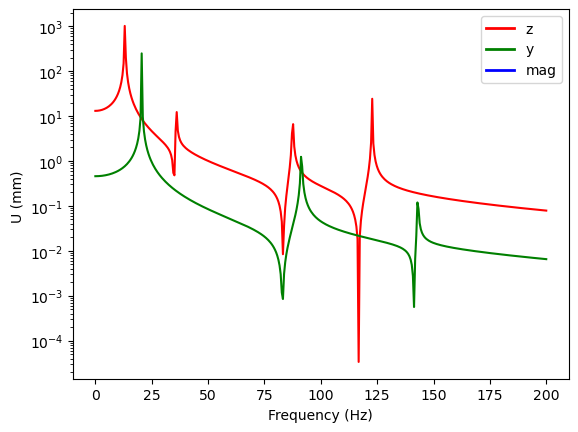

In [36]:
import math
import numpy as np
import scipy
import matplotlib.pyplot as plt
from Scripts.drone_mass import DroneMass
from Scripts.drone_battery import Battery
from Scripts.drone_geometry import DroneGeometry
from Scripts.beams import BeamType
from Scripts.mission_profile import MissionProfile
from Scripts.drone_power import DronePower
from Scripts.drone_power import BatterySystem
from Scripts.drone_forces import DroneForces
from Scripts.drone_fea import DroneFEA
import Scripts.unit_conversions as uc
import Scripts.visualization as vis
from scipy.optimize import NonlinearConstraint
from matplotlib.lines import Line2D

drag_coeff = 0.256

stress_FOS = 3
power_FOS = 1.25

allowable_deflection = 50.0 # mm

# https://store.tmotor.com/product/u8lite-l-kv95-u-efficiency.html
# Propeller Max RPM for 32in Propeller
Propeller_RPM = 3068
Propeller_Forcing_Function_Hz = Propeller_RPM / 30
Propeller_RPM_min = 1519
Propeller_Forcing_Function_Hz_min = Propeller_RPM_min / 30

print(Propeller_Forcing_Function_Hz)
print(Propeller_Forcing_Function_Hz_min)

Propeller_radius = 406.4
# spacing between propellers
Propeller_spacing = 25
arm_length = (Propeller_spacing + Propeller_radius) / math.sin(22.5 * math.pi/180)

# Battery geometry
battery_1 = Battery(4.292e-3, np.array([0, 86.75, -50]), np.array([260.5, 123.5, 63.5]))
battery_2 = Battery(4.292e-3, np.array([0, -86.75, -50]), np.array([260.5, 123.5, 63.5]))

# Mission profile generation
mission_profile = MissionProfile("m1", 1, 0, 0)
mission_profile.add_segment("takeoff",2,0,2,0,1)
mission_profile.add_segment("climb",15,550000,100000,300,0)
mission_profile.add_segment("cruise",50,2000000,110000,300,0)
mission_profile.add_segment("descent",10,2200000,50000,0,0)
mission_profile.add_segment("loiter",5,2200000,50000,0,0)
mission_profile.add_segment("land",10,2400000,0,0,0)

# Drone Power Analysis
battery_sys = BatterySystem("Tattu 40000mAh 6S 10C 22.8V High Voltage UAV Lipo Battery Pack with AS150+AS150", 22.8, 40000, 2)

arm_length = (Propeller_spacing + Propeller_radius) / math.sin(22.5 * math.pi/180)

arm_d1,arm_t,strut_d1,strut_t,strut_dist = np.array([15.0,2.5,24.0,2.0,500.0])

arm_beam_properties = BeamType("annulus", [arm_d1 + arm_t*2, arm_d1 ], "Carbon Fiber", "arm_beam")
strut_beam_properties = BeamType("annulus", [strut_d1 + strut_t*2, strut_d1 ], "Carbon Fiber", "strut_beam")

drone_geometry = DroneGeometry("drone", arm_length, strut_dist, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])

d1_fea = DroneFEA(drone_geometry)
d1_fea.create_drone_slice_nodes() # nominal radius | strut rad | number of blades
d1_fea.create_drone_slice_beams() # arm beam | strut beam
d1_fea.boundary_conditions_slice()
d1_fea.beam_system.add_force(np.array([0,0.5,6]),"outer_node")
d1_fea.solve_fea()
d1_fea.solve_natural_frequencies()

Frequencies = np.linspace(0, 200, 400)
UperF_z = np.zeros(len(Frequencies))
UperF_y = np.zeros(len(Frequencies))


UperF_mag = np.zeros(len(Frequencies))
for i, freq in enumerate(Frequencies):
    d1_fea.solve_frequency_analysis(freq*uc.Hz_to_rad_per_s)
    UperF_z[i] = abs(d1_fea.beam_system.z_displacements[2])
    UperF_y[i] = abs(d1_fea.beam_system.y_displacements[2])
    UperF_mag[i] = abs(d1_fea.beam_system.mag_displacements[2])

plt.plot(Frequencies, UperF_z, color='r')
plt.plot(Frequencies, UperF_y, color='g')
#plt.plot(Frequencies, UperF_mag, color='b')
plt.yscale('log')
plt.xlabel("Frequency (Hz)")
plt.ylabel("U (mm) ")


legend_elements = [
    Line2D([0], [0], color='r', lw=2, label='z'),
    Line2D([0], [0], color='g', lw=2, label='y'),
    Line2D([0], [0], color='b', lw=2, label='mag')
]

plt.legend(handles=legend_elements, loc='upper right')
print(d1_fea.beam_system.natural_frequencies * uc.rad_per_s_to_Hz)